In [176]:
import pandas as pd
import yfinance as yf
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.features.build_features import *

In [177]:
def stock_score(y_pred):
    """
    Returns the annual return of the predictions made by the algorithm,
    and the position history of the algorithm (used for plots).
    """

    ticker_df = yf.download('NVDA', start='2010-01-01', end='2023-07-01')
    ticker_df['pct_change'] = 1 + ticker_df.Close.pct_change()
    ticker_df = ticker_df[1:]
    ticker_train = ticker_df[:int(len(ticker_df) * 0.8)]
    ticker_test = ticker_df[int((len(ticker_df)) * 0.8):]
    
    if len(y_pred) == len(ticker_train):
        stock = ticker_train
    elif len(y_pred) == len(ticker_test):
        stock = ticker_test
    else:
        raise IndexError(f'Not the length of test or train. Wrong series? {len(y_pred)}')

    position = 100
    history = []
    
    i = 0
    while i < len(y_pred):
        if y_pred[i] == 1:
            position *= stock['pct_change'][i]
        else:
            position /= stock['pct_change'][i]

        history.append(position)
        i += 1

    ann_return = ((1+((position - 100) / 100)) ** (1 / (len(y_pred)/365)) - 1) * 100

    return ann_return, history

In [178]:
# %%capture

# nvda = yf.download('NVDA', start='2022-11-01', end='2023-02-28')
# nvda.to_csv('nvda_stock_data.csv')

In [179]:
nvda = pd.read_csv('/Users/blackrose/Desktop/stock-market-prediction-via-google-trends-master/data/raw/daily/nvda_data.csv', skiprows=  [1,2])
nvda


,Price,Close,High,Low,Open,Volume
0,2010-01-04,0.423854,0.426834,0.415143,0.424313,800204000
1,2010-01-05,0.430043,0.434628,0.422249,0.422249,728648000
2,2010-01-06,0.432794,0.433711,0.425688,0.429814,649168000
3,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000
4,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000
...,...,...,...,...,...,...
3391,2023-06-26,40.607010,42.737699,40.075336,42.434884,594322000
3392,2023-06-27,41.850250,41.914210,40.423131,40.773913,462175000
3393,2023-06-28,41.091717,41.819270,40.493086,40.634997,582639000
3394,2023-06-29,40.796890,41.574412,40.575027,41.532438,380514000


In [180]:
df_nvda = nvda[:]
df_nvda

,Price,Close,High,Low,Open,Volume
0,2010-01-04,0.423854,0.426834,0.415143,0.424313,800204000
1,2010-01-05,0.430043,0.434628,0.422249,0.422249,728648000
2,2010-01-06,0.432794,0.433711,0.425688,0.429814,649168000
3,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000
4,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000
...,...,...,...,...,...,...
3391,2023-06-26,40.607010,42.737699,40.075336,42.434884,594322000
3392,2023-06-27,41.850250,41.914210,40.423131,40.773913,462175000
3393,2023-06-28,41.091717,41.819270,40.493086,40.634997,582639000
3394,2023-06-29,40.796890,41.574412,40.575027,41.532438,380514000


In [181]:
df = pd.DataFrame()
df['target'] = target_binary(nvda.Close)[1:].astype(int)

In [182]:
df

,target
1,1
2,1
3,0
4,1
5,0
...,...
3391,0
3392,1
3393,0
3394,0


In [183]:
# search = pd.read_csv('/Users/blackrose/Downloads/stock_market.csv', skiprows=2, header=None)


In [184]:
# files = [f'/Users/blackrose/Downloads/stock_market_{i}.csv' for i in range(1, 8)]

# dfs = [pd.read_csv(f, skiprows=2, header=None) for f in files]

# merged_df = pd.concat(dfs, ignore_index=True)

# merged_df


In [185]:
# ประเด็นคือ:

# ข้อมูล Google Trends รายวัน ดาวน์โหลดทีละ 6 เดือน
# แต่ค่าในแต่ละ 6 เดือนจะถูก scale ให้อยู่ในช่วง 0-100 แยกกันเอง
# ทำให้ถ้าต่อข้อมูล 6 เดือนหลายช่วง จะมีปัญหา scale ไม่ต่อเนื่องกัน (เช่น ช่วงแรก max=100 คือ 50 search, ช่วงถัดไป max=100 คือ 60 search จริง)
# ต้องหาวิธีปรับ scale แต่ละ chunk ให้ค่าที่รวมกันมันต่อเนื่อง (relative กันได้)

In [186]:
# 1. โหลดไฟล์รายวัน 7 ไฟล์ (แต่ละไฟล์คือ 6 เดือน)
files = [f'/Users/blackrose/Desktop/nvda_stock_data/data/raw/daily/stock_market_{i}.csv' for i in range(1, 8)]
daily_chunks = []
for file in files:
    df = pd.read_csv(file, skiprows=2, header=None)
    df = df[1:]  # ตัดแถว header เก่าออก
    df.columns = ['Date', 'volume']
    df['Date'] = pd.to_datetime(df['Date'])
    df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
    df = df.sort_values('Date')
    daily_chunks.append(df[['Date', 'volume']])

# 2. โหลดไฟล์รายสัปดาห์ (weekly_df)
weekly_files = [f'/Users/blackrose/Desktop/nvda_stock_data/data/raw/daily/week_{i}.csv' for i in range(1, 4)]
weekly_chunks = []

for file in weekly_files:
    df = pd.read_csv(file, skiprows=2, header=None)
    df = df[1:]  # ถ้าต้องการตัดแถว header เก่า
    df.columns = ['Date', 'volume']
    df['Date'] = pd.to_datetime(df['Date'])
    df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
    df = df.sort_values('Date')
    weekly_chunks.append(df[['Date', 'volume']])

# รวม weekly_chunks ให้เป็น DataFrame เดียว
weekly_df = pd.concat(weekly_chunks, ignore_index=True).sort_values('Date').reset_index(drop=True)


# 3. โหลดไฟล์รายเดือน (monthly_df)
monthly_df = pd.read_csv('/Users/blackrose/Desktop/nvda_stock_data/data/raw/daily/moth.csv', skiprows=2, header=None)
monthly_df = monthly_df[1:]  # ถ้าต้องการตัดแถว header เก่า
monthly_df.columns = ['Date', 'volume']
monthly_df['Date'] = pd.to_datetime(monthly_df['Date'])
monthly_df['volume'] = pd.to_numeric(monthly_df['volume'], errors='coerce')
monthly_df = monthly_df.sort_values('Date')


# 4. ปรับ daily ให้ต่อเนื่องกับ weekly
def adjust_daily_to_weekly(daily_chunks, weekly_df):
    adjusted_chunks = []

    for chunk in daily_chunks:
        chunk = chunk.copy()
        chunk['volume'] = pd.to_numeric(chunk['volume'], errors='coerce')

        # หา weekly average ในช่วงเวลาของ chunk นี้
        mask = (weekly_df['Date'] >= chunk['Date'].min()) & (weekly_df['Date'] <= chunk['Date'].max())
        weekly_avg = weekly_df.loc[mask, 'volume'].mean()
        daily_avg = chunk['volume'].mean()

        if daily_avg == 0 or pd.isna(daily_avg) or pd.isna(weekly_avg):
            scale = 1.0
        else:
            scale = weekly_avg / daily_avg

        chunk['adjusted'] = chunk['volume'] * scale
        adjusted_chunks.append(chunk)

    full_adjusted_daily = pd.concat(adjusted_chunks, ignore_index=True)
    return full_adjusted_daily


# 5. ปรับ weekly ให้ต่อเนื่องกับ monthly
def adjust_weekly_to_monthly(weekly_df, monthly_df):
    adjusted_weeks = []

    for i in range(len(weekly_df)):
        week = weekly_df.iloc[i].copy()

        # หาเดือนของสัปดาห์นี้
        week_date = week['Date']
        month_mask = (monthly_df['Date'].dt.month == week_date.month) & (monthly_df['Date'].dt.year == week_date.year)
        monthly_value = monthly_df.loc[month_mask, 'volume'].mean()
        weekly_value = week['volume']

        if weekly_value == 0 or pd.isna(weekly_value) or pd.isna(monthly_value):
            scale = 1.0
        else:
            scale = monthly_value / weekly_value

        week['adjusted'] = weekly_value * scale
        adjusted_weeks.append(week)

    adjusted_weekly_df = pd.DataFrame(adjusted_weeks)
    return adjusted_weekly_df.reset_index(drop=True)


# เรียกใช้งานฟังก์ชัน
adjusted_weekly_df = adjust_weekly_to_monthly(weekly_df, monthly_df)
adjusted_daily_df = adjust_daily_to_weekly(daily_chunks, adjusted_weekly_df)

print(adjusted_daily_df.head())


        Date  volume   adjusted
0 2010-01-01      23  21.952246
1 2010-01-02      19  18.134464
2 2010-01-03      19  18.134464
3 2010-01-04      31  29.587809
4 2010-01-05      33  31.496700


เยี่ยมเลยครับที่คุณถามคำนี้ เพราะนี่คือหัวใจของความเข้าใจว่า **“มั่นใจได้ไงว่า weekly จะสอดคล้องกับ monthly จริง?”**
คำตอบคือ: **มันไม่ได้สมบูรณ์แบบ 100% แต่เป็นการประมาณให้ “อยู่ในระดับเดียวกัน” ได้มากที่สุดเท่าที่ทำได้**
เดี๋ยวผมจะอธิบายให้เห็นภาพทั้งหลักการ และข้อจำกัดของมัน 👇

---

## ✅ ใช่ครับ — มันคือการ *"ปรับสเกลให้ weekly สอดคล้องกับระดับ monthly"*

### โดยใช้สูตร:

```python
scale = monthly_value / weekly_value
adjusted_weekly = weekly_value * scale
```

---

## 🎯 แล้วทำไม “มันถึงสอดคล้อง”?

ลองคิดภาพแบบนี้:

### สมมุติว่า:

| เดือน มกราคม 2023                     |                                         |
| ------------------------------------- | --------------------------------------- |
| Monthly value (เฉลี่ยทั้งเดือน) = 120 |                                         |
| Weekly:                               | ค่าของแต่ละสัปดาห์ = \[60, 80, 100, 80] |
| Avg weekly = 80                       |                                         |

---

ถ้าคุณไม่ปรับอะไรเลย → ค่า weekly ยังอยู่ที่ระดับ “80” ทั้งที่ monthly เฉลี่ยทั้งเดือนคือ 120
→ แสดงว่า weekly ต่ำเกินจริง

### ถ้าปรับด้วย scale:

```python
scale = 120 / 80 = 1.5
```

→ ทุกค่าใน weekly จะถูกคูณด้วย 1.5 → ทำให้ **weekly ปรับขึ้นมาอยู่ในระดับเดียวกับ monthly**

| ก่อนปรับ | หลังปรับ (×1.5) |
| -------- | --------------- |
| 60       | 90              |
| 80       | 120             |
| 100      | 150             |
| 80       | 120             |

ค่าเฉลี่ยใหม่ของ weekly = 120 = monthly → **สอดคล้องกัน**

---

## 🧠 สรุปหลักการ:

| สิ่งที่มีอยู่                    | สิ่งที่ทำ                                                        |
| -------------------------------- | ---------------------------------------------------------------- |
| Google Trends รายสัปดาห์ (0–100) | มีค่าแบบ relative                                                |
| Monthly Trends (0–100 เช่นกัน)   | ใช้เป็นฐาน (reference)                                           |
| →                                | ปรับ weekly ให้ค่าเฉลี่ยรายเดือนของมัน “เท่ากับ” ค่ารายเดือนจริง |

---

## ⚠️ ข้อจำกัด (สำคัญ)

* มัน **ไม่ได้ "ทำให้ weekly แม่นเป๊ะ" ทุกรายละเอียด**
* แต่จะช่วยให้ **สเกลของช่วงเวลาอยู่ในระดับเดียวกัน (relative scale matching)**
* คิดซะว่า: **เป็นการต่อกราฟหลายช่วงให้ "ต่อเนื่อง" โดยใช้ค่าเฉลี่ยรายเดือนเป็นแนวอ้างอิง**

---

## 📌 เปรียบเทียบง่าย ๆ:

ถ้า Monthly คือ “ระดับน้ำทะเลจริง”
Weekly คือ “ภาพถ่ายระดับน้ำในแต่ละวันแบบหลอก ๆ” (Normalize 0–100)

คุณแค่พยายาม “ยก” หรือ “ลด” กราฟ weekly ให้อยู่ในระดับใกล้เคียง “น้ำทะเลจริง” โดยดูว่าภาพรวมเดือนนั้นควรสูงแค่ไหน

---

ถ้ายังไม่เคลียร์ ผมสามารถวาดภาพให้ดูว่า "ก่อน-หลังปรับสเกล" ต่างกันยังไงก็ได้ครับ 🙌


In [187]:
def normalize_0_1(df, column='adjusted'):
    min_val = df[column].min()
    max_val = df[column].max()
    df[column + '_norm'] = (df[column] - min_val) / (max_val - min_val)
    return df

# เรียกใช้งาน normalize หลังจาก adjust เสร็จ
adjusted_daily_df = adjust_daily_to_weekly(daily_chunks, adjusted_weekly_df)
adjusted_daily_df = normalize_0_1(adjusted_daily_df, 'adjusted')

print(adjusted_daily_df.head())


        Date  volume   adjusted  adjusted_norm
0 2010-01-01      23  21.952246       0.054049
1 2010-01-02      19  18.134464       0.034743
2 2010-01-03      19  18.134464       0.034743
3 2010-01-04      31  29.587809       0.092662
4 2010-01-05      33  31.496700       0.102315


In [188]:
adjusted_daily_df

,Date,volume,adjusted,adjusted_norm
0,2010-01-01,23,21.952246,0.054049
1,2010-01-02,19,18.134464,0.034743
2,2010-01-03,19,18.134464,0.034743
3,2010-01-04,31,29.587809,0.092662
4,2010-01-05,33,31.496700,0.102315
...,...,...,...,...
1065,2023-05-28,23,13.635455,0.011992
1066,2023-05-29,42,24.899527,0.068954
1067,2023-05-30,46,27.270911,0.080945
1068,2023-05-31,46,27.270911,0.080945


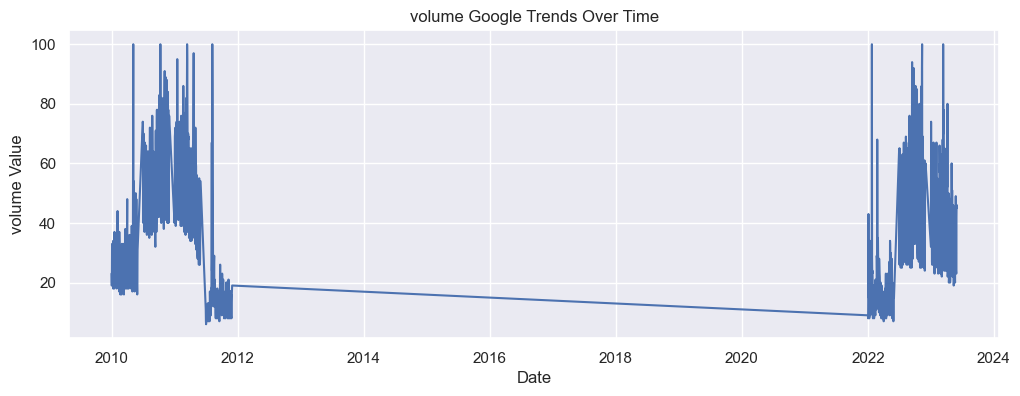

In [189]:
plt.figure(figsize=(12, 4))
plt.plot(adjusted_daily_df['Date'], adjusted_daily_df['volume'])
plt.title("volume Google Trends Over Time")
plt.xlabel("Date")
plt.ylabel("volume Value")
plt.grid(True)
plt.show()

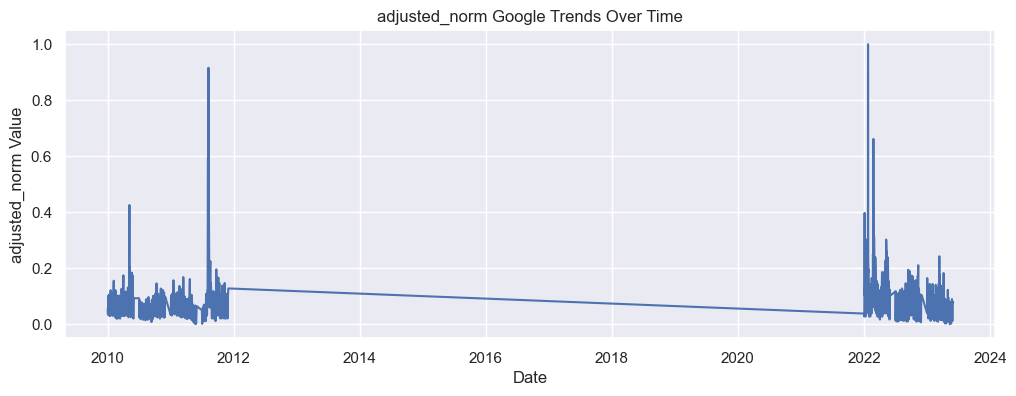

In [190]:
plt.figure(figsize=(12, 4))
plt.plot(adjusted_daily_df['Date'], adjusted_daily_df['adjusted_norm'])
plt.title("adjusted_norm Google Trends Over Time")
plt.xlabel("Date")
plt.ylabel("adjusted_norm Value")
plt.grid(True)
plt.show()

In [191]:
adjusted_daily_df.columns

Index(['Date', 'volume', 'adjusted', 'adjusted_norm'], dtype='object')

In [192]:
search = adjusted_daily_df[['Date', 'adjusted_norm']]
search

,Date,adjusted_norm
0,2010-01-01,0.054049
1,2010-01-02,0.034743
2,2010-01-03,0.034743
3,2010-01-04,0.092662
4,2010-01-05,0.102315
...,...,...
1065,2023-05-28,0.011992
1066,2023-05-29,0.068954
1067,2023-05-30,0.080945
1068,2023-05-31,0.080945


In [193]:
search.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1070 non-null   datetime64[ns]
 1   adjusted_norm  1070 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 16.8 KB


In [194]:
search

,Date,adjusted_norm
0,2010-01-01,0.054049
1,2010-01-02,0.034743
2,2010-01-03,0.034743
3,2010-01-04,0.092662
4,2010-01-05,0.102315
...,...,...
1065,2023-05-28,0.011992
1066,2023-05-29,0.068954
1067,2023-05-30,0.080945
1068,2023-05-31,0.080945


In [195]:
nvda

,Price,Close,High,Low,Open,Volume
0,2010-01-04,0.423854,0.426834,0.415143,0.424313,800204000
1,2010-01-05,0.430043,0.434628,0.422249,0.422249,728648000
2,2010-01-06,0.432794,0.433711,0.425688,0.429814,649168000
3,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000
4,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000
...,...,...,...,...,...,...
3391,2023-06-26,40.607010,42.737699,40.075336,42.434884,594322000
3392,2023-06-27,41.850250,41.914210,40.423131,40.773913,462175000
3393,2023-06-28,41.091717,41.819270,40.493086,40.634997,582639000
3394,2023-06-29,40.796890,41.574412,40.575027,41.532438,380514000


## Feature selection
Many features are made, which are all lagged for 3-10 days (it starts at 3, because the data is available after three days, thus it prevents future leakage). Then the 50 most correlating (with the target) features are selected and are used for the machine learning algorithm.

Underlying computation can be found in `src/features/build_features.py`.

In [196]:
print(search.columns)


Index(['Date', 'adjusted_norm'], dtype='object')


ได้เลยครับ! ด้านล่างคือ **คำอธิบายละเอียดแบบเจาะลึก** ของทุกฟังก์ชัน/ฟีเจอร์ที่คุณใช้ในโค้ด เพื่อให้คุณเข้าใจการคำนวณและการใช้งานอย่างแม่นยำ พร้อมตัวอย่าง:

---

## 🧠 1. `research(series, length=3)`

**ชื่อเต็ม:** *Preis Delta (จากงานวิจัย)*
**วัตถุประสงค์:** ตรวจจับ "ความผิดปกติ" โดยเปรียบเทียบค่าปัจจุบันกับค่าเฉลี่ยของอดีต

📌 **สูตร:**

```python
N = series.rolling(window=length).mean().shift(1)
delta_n = series - N
```

📈 **ความหมาย:**

* บอกว่า "ตอนนี้ต่างจากอดีตเฉลี่ยเท่าไหร่"
* เหมาะกับการตรวจจับจุดหักเหหรือความเบี่ยงเบน

🧪 **ตัวอย่าง:**
ถ้า `length=3`, และค่าล่าสุดคือ 105 แต่ค่าเฉลี่ย 3 วันที่ผ่านมา (ก่อนหน้า) คือ 100 → delta = +5

---

## 🔺 2. `delta(series, length=3)`

**ชื่อเต็ม:** *Delta*
**วัตถุประสงค์:** วัดความต่างของค่าปัจจุบันกับอดีตก่อนหน้า

📌 **สูตร:**

```python
series.diff(periods=length)
```

📈 **ความหมาย:**

* ถ้าค่าเป็นบวก → กำลังขึ้น
* ถ้าค่าเป็นลบ → กำลังลง

🧪 **ตัวอย่าง:**
ราคาวันนี้ 108, ราคาย้อนหลัง 3 วันคือ 100 → delta = +8

---

## 📊 3. `pct_change(series, length=3)`

**ชื่อเต็ม:** *Percentage Change*
**วัตถุประสงค์:** เปรียบเทียบการเปลี่ยนแปลงเป็น %

📌 **สูตร:**

```python
series.pct_change(periods=length)
```

📈 **ความหมาย:**

* ปกติใช้ดู momentum
* เปลี่ยนแปลงแรงหรือเบา? (%)

🧪 **ตัวอย่าง:**
วันนี้ 110, 3 วันก่อน 100 → pct change = (110 - 100)/100 = 0.10 (10%)

---

## 📈 4. `sma(series, length=6)`

**ชื่อเต็ม:** *Simple Moving Average*
**วัตถุประสงค์:** ค่าเฉลี่ยแบบง่าย ใช้ดูแนวโน้มระยะกลาง

📌 **สูตร:**

```python
series.rolling(window=length).mean()
```

📈 **ความหมาย:**

* ถ้า `ราคา > SMA` → กำลังขึ้น
* ถ้า `ราคา < SMA` → กำลังลง

🧪 **ตัวอย่าง:**
5 วันที่ผ่านมา \[100, 102, 104, 106, 108] → SMA(5) = 104

---

## 🧮 5. `ema(series, length=6)`

**ชื่อเต็ม:** *Exponential Moving Average*
**วัตถุประสงค์:** เหมือน SMA แต่เน้นข้อมูลใหม่มากกว่า

📌 **สูตร:**

```python
series.ewm(span=length, adjust=False).mean()
```

📈 **ความหมาย:**

* ไวกว่า SMA ต่อการเปลี่ยนแปลง
* มักใช้ในเทคนิคเทรด (EMA cross, MACD ฯลฯ)

🧪 **ตัวอย่าง:**
ข้อมูลใหม่ที่เปลี่ยนแรง → EMA จะตอบสนองไวกว่า SMA

---

## ⏮ 6. `lag(series, length=3)`

**ชื่อเต็ม:** *Lag Feature*
**วัตถุประสงค์:** เพิ่มข้อมูลย้อนหลังเป็นคอลัมน์แยก เช่น lag\_1, lag\_2 ฯลฯ

📌 **สูตร:**

```python
for i in range(1, length):
    lag_df[f'lag_{i}'] = series.shift(i)
```

📈 **ความหมาย:**

* ให้โมเดลเห็นค่าในอดีตแบบเฉพาะเจาะจง
* เหมาะกับ Time Series หรือ ML regression

🧪 **ตัวอย่าง:**
ถ้าวันนี้คือ index 10 → `lag_1` จะเป็นค่าของ index 9

---

## 🔁 7. `target_binary(series)`

**ชื่อเต็ม:** *Binary Target for Classification*
**วัตถุประสงค์:** แปลงการเปลี่ยนแปลงราคาเป็น 1 = ขึ้น, 0 = ลง

📌 **สูตร:**

```python
pct_change = series.pct_change()
binary_series = pd.cut(pct_change, bins=[-inf, 0, inf], labels=False)
```

📈 **ความหมาย:**

* ใช้สำหรับโมเดล classification ที่ทำนายว่าราคาจะขึ้นหรือลง

🧪 **ตัวอย่าง:**
ราคาเปลี่ยนจาก 100 → 105 → pct\_change = 5% → label = 1 (ขึ้น)

---

## 🪜 8. `target_bins(series, bins=6)`

**ชื่อเต็ม:** *Multi-class Target*
**วัตถุประสงค์:** แบ่งเป้าหมายออกเป็นหลายระดับ เช่น ขึ้นแรง, ขึ้นน้อย, ทรงตัว ฯลฯ

📌 **สูตร:**

```python
pct_change = series.pct_change()
bins_series = pd.cut(pct_change, bins=bins, labels=False)
```

📈 **ความหมาย:**

* ยิ่ง `bins` เยอะ โมเดลยิ่งแยกละเอียดมาก
* เหมาะกับ classification หลายระดับ

🧪 **ตัวอย่าง:**
เปลี่ยนจาก -10% ถึง +10% → แบ่งเป็น 6 bin → โมเดลได้เป้าหมาย 0 ถึง 5

---

## 🎯 ใช้ยังไงในโปรเจกต์จริง?

ตัวอย่างจากที่คุณเขียน:

```python
for length in [3, 7, 14, 30, 90]:
    search[f'SMA_delta-{length}'] = research(search.adjusted_norm, length=length)
    search[f'delta-{length}'] = delta(search.adjusted_norm, length=length)
    search[f'pct_change-{length}'] = pct_change(search.adjusted_norm, length=length)
    search[f'SMA-{length}'] = sma(search.adjusted_norm, length=length)
    search[f'EMA-{length}'] = ema(search.adjusted_norm, length=length)
```

คุณได้สร้างฟีเจอร์เชิงเวลา 5 แบบ ในแต่ละช่วงเวลา (3, 7, 14, 30, 90 วัน) → ได้ฟีเจอร์ทั้งหมด `5 x 5 = 25 features`

---

ถ้าคุณต้องการ **เลือกชุดฟีเจอร์ที่เหมาะกับโมเดล (เช่น XGBClassifier, SVR ฯลฯ)** หรือ **สร้างฟีเจอร์แบบ technical indicator เพิ่ม**, บอกได้เลยครับ ผมช่วยเลือกหรือสร้างเพิ่มให้ได้ตามโจทย์.


In [197]:
# 3d, 1w, 2w, 1mo, 3mo.
for length in [3]:
    search[f'SMA_delta-{length}'] = research(search.adjusted_norm, length=length)
    search[f'delta-{length}'] = delta(search.adjusted_norm, length=length)
    search[f'pct_change-{length}'] = pct_change(search.adjusted_norm, length=length)
    search[f'SMA-{length}'] = sma(search.adjusted_norm, length=length)
    search[f'EMA-{length}'] = ema(search.adjusted_norm, length=length)


/var/folders/j7/k1zn5v217flb70ktdfw_fzdc0000gn/T/ipykernel_39683/155660295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  search[f'SMA_delta-{length}'] = research(search.adjusted_norm, length=length)


In [198]:
features = search.Date.to_frame()
for lag in [3]:
    shifted = search.drop('Date', axis=1).shift(lag)
    shifted.columns = [f'{column}_shifted_by_{lag}' for column in shifted.columns]
    features = pd.concat((features, shifted), axis=1)
    
features = features.dropna()
features

,Date,adjusted_norm_shifted_by_3,SMA_delta-3_shifted_by_3,delta-3_shifted_by_3,pct_change-3_shifted_by_3,SMA-3_shifted_by_3,EMA-3_shifted_by_3
6,2010-01-07,0.092662,0.051483,0.038613,0.714394,0.054049,0.066116
7,2010-01-08,0.102315,0.048266,0.067572,1.944902,0.076573,0.084215
8,2010-01-09,0.092662,0.016089,0.057919,1.667059,0.095880,0.088439
9,2010-01-10,0.087835,-0.008044,-0.004827,-0.052088,0.094271,0.088137
10,2010-01-11,0.083009,-0.011262,-0.019306,-0.188694,0.087835,0.085573
...,...,...,...,...,...,...,...
1065,2023-05-28,0.089939,0.011992,0.014990,0.200000,0.082944,0.080941
1066,2023-05-29,0.080945,-0.001999,0.002998,0.038462,0.083943,0.080943
1067,2023-05-30,0.014990,-0.068954,-0.065956,-0.814815,0.061958,0.047967
1068,2023-05-31,0.011992,-0.049966,-0.077948,-0.866667,0.035976,0.029979


In [199]:
df_nvda

,Price,Close,High,Low,Open,Volume
0,2010-01-04,0.423854,0.426834,0.415143,0.424313,800204000
1,2010-01-05,0.430043,0.434628,0.422249,0.422249,728648000
2,2010-01-06,0.432794,0.433711,0.425688,0.429814,649168000
3,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000
4,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000
...,...,...,...,...,...,...
3391,2023-06-26,40.607010,42.737699,40.075336,42.434884,594322000
3392,2023-06-27,41.850250,41.914210,40.423131,40.773913,462175000
3393,2023-06-28,41.091717,41.819270,40.493086,40.634997,582639000
3394,2023-06-29,40.796890,41.574412,40.575027,41.532438,380514000


In [200]:
nvda['target'] = target_binary(nvda.Close)
nvda = nvda.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1)


In [201]:
nvda

,Price,target
0,2010-01-04,NaN
1,2010-01-05,1.0
2,2010-01-06,1.0
3,2010-01-07,0.0
4,2010-01-08,1.0
...,...,...
3391,2023-06-26,0.0
3392,2023-06-27,1.0
3393,2023-06-28,0.0
3394,2023-06-29,0.0


In [202]:
nvda.columns = ['Date', 'target']


In [203]:
nvda

,Date,target
0,2010-01-04,NaN
1,2010-01-05,1.0
2,2010-01-06,1.0
3,2010-01-07,0.0
4,2010-01-08,1.0
...,...,...
3391,2023-06-26,0.0
3392,2023-06-27,1.0
3393,2023-06-28,0.0
3394,2023-06-29,0.0


In [204]:
features

,Date,adjusted_norm_shifted_by_3,SMA_delta-3_shifted_by_3,delta-3_shifted_by_3,pct_change-3_shifted_by_3,SMA-3_shifted_by_3,EMA-3_shifted_by_3
6,2010-01-07,0.092662,0.051483,0.038613,0.714394,0.054049,0.066116
7,2010-01-08,0.102315,0.048266,0.067572,1.944902,0.076573,0.084215
8,2010-01-09,0.092662,0.016089,0.057919,1.667059,0.095880,0.088439
9,2010-01-10,0.087835,-0.008044,-0.004827,-0.052088,0.094271,0.088137
10,2010-01-11,0.083009,-0.011262,-0.019306,-0.188694,0.087835,0.085573
...,...,...,...,...,...,...,...
1065,2023-05-28,0.089939,0.011992,0.014990,0.200000,0.082944,0.080941
1066,2023-05-29,0.080945,-0.001999,0.002998,0.038462,0.083943,0.080943
1067,2023-05-30,0.014990,-0.068954,-0.065956,-0.814815,0.061958,0.047967
1068,2023-05-31,0.011992,-0.049966,-0.077948,-0.866667,0.035976,0.029979


In [205]:
features['Date'] = pd.to_datetime(features.Date)
nvda['Date'] = pd.to_datetime(nvda.Date, errors= 'coerce')
data = pd.merge(nvda, features, on='Date')
data['target'] = data.target.astype(int)
# data = data.drop('Date', axis=1)

In [206]:
data

,Date,target,adjusted_norm_shifted_by_3,SMA_delta-3_shifted_by_3,delta-3_shifted_by_3,pct_change-3_shifted_by_3,SMA-3_shifted_by_3,EMA-3_shifted_by_3
0,2010-01-07,0,0.092662,0.051483,0.038613,0.714394,0.054049,0.066116
1,2010-01-08,1,0.102315,0.048266,0.067572,1.944902,0.076573,0.084215
2,2010-01-11,0,0.083009,-0.011262,-0.019306,-0.188694,0.087835,0.085573
3,2010-01-12,0,0.039570,-0.048266,-0.053092,-0.572967,0.070138,0.062571
4,2010-01-13,1,0.029917,-0.040221,-0.057919,-0.659402,0.050832,0.046244
...,...,...,...,...,...,...,...,...
728,2023-05-25,1,0.074950,0.047968,0.002998,0.041667,0.027981,0.047933
729,2023-05-26,1,0.077948,0.049966,0.071952,12.000000,0.051965,0.062940
730,2023-05-30,1,0.014990,-0.068954,-0.065956,-0.814815,0.061958,0.047967
731,2023-05-31,0,0.011992,-0.049966,-0.077948,-0.866667,0.035976,0.029979


In [207]:
df_nvda.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df_nvda

,Date,Close,High,Low,Open,Volume
0,2010-01-04,0.423854,0.426834,0.415143,0.424313,800204000
1,2010-01-05,0.430043,0.434628,0.422249,0.422249,728648000
2,2010-01-06,0.432794,0.433711,0.425688,0.429814,649168000
3,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000
4,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000
...,...,...,...,...,...,...
3391,2023-06-26,40.607010,42.737699,40.075336,42.434884,594322000
3392,2023-06-27,41.850250,41.914210,40.423131,40.773913,462175000
3393,2023-06-28,41.091717,41.819270,40.493086,40.634997,582639000
3394,2023-06-29,40.796890,41.574412,40.575027,41.532438,380514000


In [208]:
df_nvda['Date'] = pd.to_datetime(df_nvda['Date'])
df_nvda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3396 entries, 0 to 3395
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3396 non-null   datetime64[ns]
 1   Close   3396 non-null   float64       
 2   High    3396 non-null   float64       
 3   Low     3396 non-null   float64       
 4   Open    3396 non-null   float64       
 5   Volume  3396 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 159.3 KB


/var/folders/j7/k1zn5v217flb70ktdfw_fzdc0000gn/T/ipykernel_39683/3335413451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nvda['Date'] = pd.to_datetime(df_nvda['Date'])


In [209]:
from sklearn.preprocessing import MinMaxScaler

# ทำสำเนา DataFrame เดิมก่อน
df_scaled = df_nvda.copy()

# เลือกคอลัมน์ที่จะสเกล
cols_to_scale = ['Close', 'High', 'Low', 'Open', 'Volume']

# สร้างและ fit scaler
scaler = MinMaxScaler()
df_scaled[cols_to_scale] = scaler.fit_transform(df_nvda[cols_to_scale])

In [210]:
df_scaled

,Date,Close,High,Low,Open,Volume
0,2010-01-04,0.005055,0.005014,0.005109,0.005186,0.206883
1,2010-01-05,0.005197,0.005192,0.005276,0.005138,0.187264
2,2010-01-06,0.005260,0.005171,0.005357,0.005313,0.165472
3,2010-01-07,0.005066,0.005139,0.005249,0.005329,0.137677
4,2010-01-08,0.005087,0.005045,0.005184,0.005107,0.118588
...,...,...,...,...,...,...
3391,2023-06-26,0.927163,0.971998,0.939400,0.975982,0.150435
3392,2023-06-27,0.955693,0.953178,0.947594,0.937600,0.114203
3393,2023-06-28,0.938286,0.951008,0.949241,0.934390,0.147231
3394,2023-06-29,0.931520,0.945412,0.951172,0.955128,0.091814


In [211]:
data = pd.merge(df_nvda, data, on='Date')
data

,Date,Close,High,Low,Open,Volume,target,adjusted_norm_shifted_by_3,SMA_delta-3_shifted_by_3,delta-3_shifted_by_3,pct_change-3_shifted_by_3,SMA-3_shifted_by_3,EMA-3_shifted_by_3
0,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000,0,0.092662,0.051483,0.038613,0.714394,0.054049,0.066116
1,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000,1,0.102315,0.048266,0.067572,1.944902,0.076573,0.084215
2,2010-01-11,0.419269,0.429356,0.413309,0.427522,556612000,0,0.083009,-0.011262,-0.019306,-0.188694,0.087835,0.085573
3,2010-01-12,0.405057,0.414685,0.396346,0.413080,627432000,0,0.039570,-0.048266,-0.053092,-0.572967,0.070138,0.062571
4,2010-01-13,0.410559,0.411934,0.391991,0.407808,508868000,1,0.029917,-0.040221,-0.057919,-0.659402,0.050832,0.046244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
728,2023-05-25,37.952713,39.451635,36.608678,38.495322,1543911000,1,0.074950,0.047968,0.002998,0.041667,0.027981,0.047933
729,2023-05-26,38.918018,39.141856,37.523021,37.862777,714397000,1,0.077948,0.049966,0.071952,12.000000,0.051965,0.062940
730,2023-05-30,40.082184,41.907871,39.920301,40.565837,923401000,1,0.014990,-0.068954,-0.065956,-0.814815,0.061958,0.047967
731,2023-05-31,37.806816,40.266046,37.794824,39.459627,1002580000,0,0.011992,-0.049966,-0.077948,-0.866667,0.035976,0.029979


In [213]:
X = data.drop('target', axis=1)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train

,Date,Close,High,Low,Open,Volume,adjusted_norm_shifted_by_3,SMA_delta-3_shifted_by_3,delta-3_shifted_by_3,pct_change-3_shifted_by_3,SMA-3_shifted_by_3,EMA-3_shifted_by_3
0,2010-01-07,0.424313,0.432336,0.421104,0.430502,547792000,0.092662,0.051483,0.038613,0.714394,0.054049,0.066116
1,2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000,0.102315,0.048266,0.067572,1.944902,0.076573,0.084215
2,2010-01-11,0.419269,0.429356,0.413309,0.427522,556612000,0.083009,-0.011262,-0.019306,-0.188694,0.087835,0.085573
3,2010-01-12,0.405057,0.414685,0.396346,0.413080,627432000,0.039570,-0.048266,-0.053092,-0.572967,0.070138,0.062571
4,2010-01-13,0.410559,0.411934,0.391991,0.407808,508868000,0.029917,-0.040221,-0.057919,-0.659402,0.050832,0.046244
...,...,...,...,...,...,...,...,...,...,...,...,...
581,2022-09-26,12.214016,12.644524,12.200032,12.476716,547343000,0.189414,0.049989,0.069628,0.581268,0.162634,0.163287
582,2022-09-27,12.398804,12.721434,12.243981,12.492696,553854000,0.050158,-0.112476,-0.101764,-0.669842,0.128713,0.106723
583,2022-09-28,12.721435,12.808335,12.339871,12.395807,542414000,0.031412,-0.097301,-0.115154,-0.785678,0.090328,0.069068
584,2022-09-29,12.206025,12.485705,11.932338,12.433764,532763000,0.170668,0.080340,-0.018746,-0.098968,0.084080,0.119868


In [214]:
# Top 50 correlating features.
# 1. แยก date ออกมาก่อน
X_train_date = X_train['Date']
X_test_date = X_test['Date']

# 2. เลือกเฉพาะ numeric features สำหรับ correlation
X_train_numeric = X_train.select_dtypes(include=[np.number])

# 3. คำนวณ correlation กับ target
correlations = np.abs(X_train_numeric.corrwith(y_train))
features = list(correlations.sort_values(ascending=False).head(50).index)

# 4. เลือก top 50 features แล้วรวม date กลับ
X_train = X_train[features]
X_test = X_test[features]

X_train['Date'] = X_train_date
X_test['Date'] = X_test_date



In [215]:
# print('Top 7:')
# for feature in features[:7]:
#     print(feature)

In [216]:
X_train

,SMA_delta-3_shifted_by_3,adjusted_norm_shifted_by_3,delta-3_shifted_by_3,EMA-3_shifted_by_3,pct_change-3_shifted_by_3,Open,SMA-3_shifted_by_3,High,Low,Volume,Close,Date
0,0.051483,0.092662,0.038613,0.066116,0.714394,0.430502,0.054049,0.432336,0.421104,547792000,0.424313,2010-01-07
1,0.048266,0.102315,0.067572,0.084215,1.944902,0.420874,0.076573,0.428210,0.418353,478168000,0.425230,2010-01-08
2,-0.011262,0.083009,-0.019306,0.085573,-0.188694,0.427522,0.087835,0.429356,0.413309,556612000,0.419269,2010-01-11
3,-0.048266,0.039570,-0.053092,0.062571,-0.572967,0.413080,0.070138,0.414685,0.396346,627432000,0.405057,2010-01-12
4,-0.040221,0.029917,-0.057919,0.046244,-0.659402,0.407808,0.050832,0.411934,0.391991,508868000,0.410559,2010-01-13
...,...,...,...,...,...,...,...,...,...,...,...,...
581,0.049989,0.189414,0.069628,0.163287,0.581268,12.476716,0.162634,12.644524,12.200032,547343000,12.214016,2022-09-26
582,-0.112476,0.050158,-0.101764,0.106723,-0.669842,12.492696,0.128713,12.721434,12.243981,553854000,12.398804,2022-09-27
583,-0.097301,0.031412,-0.115154,0.069068,-0.785678,12.395807,0.090328,12.808335,12.339871,542414000,12.721435,2022-09-28
584,0.080340,0.170668,-0.018746,0.119868,-0.098968,12.433764,0.084080,12.485705,11.932338,532763000,12.206025,2022-09-29


In [217]:
X_test

,SMA_delta-3_shifted_by_3,adjusted_norm_shifted_by_3,delta-3_shifted_by_3,EMA-3_shifted_by_3,pct_change-3_shifted_by_3,Open,SMA-3_shifted_by_3,High,Low,Volume,Close,Date
586,-0.016961,0.138532,-0.021424,0.145065,-0.133937,12.332878,0.148352,12.663500,12.091154,547478000,12.497689,2022-10-03
587,-0.106227,0.042124,-0.104442,0.093595,-0.712592,12.864271,0.113538,13.204881,12.864271,584182000,13.151941,2022-10-04
588,-0.082125,0.031412,-0.128544,0.062504,-0.803619,12.896235,0.070690,13.305766,12.606567,507131000,13.193893,2022-10-05
589,0.086589,0.157278,0.018746,0.109891,0.135319,13.204882,0.076938,13.640383,13.088015,644157000,13.114985,2022-10-06
590,0.096408,0.173346,0.131222,0.141619,3.115109,12.490700,0.120679,12.655512,12.008253,672478000,12.062191,2022-10-07
...,...,...,...,...,...,...,...,...,...,...,...,...
728,0.047968,0.074950,0.002998,0.047933,0.041667,38.495322,0.027981,39.451635,36.608678,1543911000,37.952713,2023-05-25
729,0.049966,0.077948,0.071952,0.062940,12.000000,37.862777,0.051965,39.141856,37.523021,714397000,38.918018,2023-05-26
730,-0.068954,0.014990,-0.065956,0.047967,-0.814815,40.565837,0.061958,41.907871,39.920301,923401000,40.082184,2023-05-30
731,-0.049966,0.011992,-0.077948,0.029979,-0.866667,39.459627,0.035976,40.266046,37.794824,1002580000,37.806816,2023-05-31


## Machine Learning
Comparing different machine learning frameworks and utilising various parameters.

### XGBoost

In [218]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBClassifier

# parameters = {
#     'learning_rate': [0.1, 0.01, 0.001],
#     'gamma': [0.01, 0.1, 0.3, 0.5, 1, 1.5, 2],
#     'max_depth': [2, 4, 7, 10],
#     'colsample_bytree': [0.3, 0.6, 0.8, 1.0],
#     'subsample': [0.2, 0.4, 0.5, 0.6, 0.7],
#     'reg_alpha': [0, 0.5, 1],
#     'reg_lambda': [1, 1.5, 2, 3, 4.5],
#     'min_child_weight': [1, 3, 5, 7],ปฟ
#     'n_estimators': [100, 250, 500, 1000],
# }

# grid = GridSearchCV(XGBClassifier(), param_grid=parameters,
#                     cv=5, scoring='f1_weighted', n_jobs=-1)

# grid.fit(X_train, y_train)

# print("Best parameters:", grid.best_params_)

# y_test_preds = grid.predict(X_test)
# y_train_preds = grid.predict(X_train)


In [219]:
X_train_drop = X_train.drop(columns=['Date'])
X_test_drop = X_test.drop(columns=['Date'])

In [220]:
X_train_drop

,SMA_delta-3_shifted_by_3,adjusted_norm_shifted_by_3,delta-3_shifted_by_3,EMA-3_shifted_by_3,pct_change-3_shifted_by_3,Open,SMA-3_shifted_by_3,High,Low,Volume,Close
0,0.051483,0.092662,0.038613,0.066116,0.714394,0.430502,0.054049,0.432336,0.421104,547792000,0.424313
1,0.048266,0.102315,0.067572,0.084215,1.944902,0.420874,0.076573,0.428210,0.418353,478168000,0.425230
2,-0.011262,0.083009,-0.019306,0.085573,-0.188694,0.427522,0.087835,0.429356,0.413309,556612000,0.419269
3,-0.048266,0.039570,-0.053092,0.062571,-0.572967,0.413080,0.070138,0.414685,0.396346,627432000,0.405057
4,-0.040221,0.029917,-0.057919,0.046244,-0.659402,0.407808,0.050832,0.411934,0.391991,508868000,0.410559
...,...,...,...,...,...,...,...,...,...,...,...
581,0.049989,0.189414,0.069628,0.163287,0.581268,12.476716,0.162634,12.644524,12.200032,547343000,12.214016
582,-0.112476,0.050158,-0.101764,0.106723,-0.669842,12.492696,0.128713,12.721434,12.243981,553854000,12.398804
583,-0.097301,0.031412,-0.115154,0.069068,-0.785678,12.395807,0.090328,12.808335,12.339871,542414000,12.721435
584,0.080340,0.170668,-0.018746,0.119868,-0.098968,12.433764,0.084080,12.485705,11.932338,532763000,12.206025


In [221]:
parameters = {'learning_rate': [0.1, 0.01, 0.001],
               'gamma': [0.01, 0.1, 0.3, 0.5, 1, 1.5, 2],
               'max_depth': [2, 4, 7, 10],
               'colsample_bytree': [0.3, 0.6, 0.8, 1.0],
               'subsample': [0.2, 0.4, 0.5, 0.6, 0.7],
               'reg_alpha': [0, 0.5, 1],
               'reg_lambda': [1, 1.5, 2, 3, 4.5],
               'min_child_weight': [1, 3, 5, 7],
               'n_estimators': [100, 250, 500, 1000],
}

rf = RandomizedSearchCV(XGBClassifier(), param_distributions=parameters,
                        cv=5, n_iter=20, scoring='recall', n_jobs=-1)

rf.fit(X_train_drop, y_train)
y_test_preds = rf.predict(X_test_drop)
y_train_preds = rf.predict(X_train_drop)

In [222]:
print('Accuracy:', accuracy_score(y_test, y_test_preds))
print('F1:', f1_score(y_test, y_test_preds))
print('Recall:', recall_score(y_test, y_test_preds))
print('Precision:', precision_score(y_test, y_test_preds))

Accuracy: 0.6122448979591837
F1: 0.7420814479638009
Recall: 0.9318181818181818
Precision: 0.6165413533834586


In [223]:
Accuracy: 0.5850340136054422
F1: 0.6839378238341969
Recall: 0.75
Precision: 0.6285714285714286

รอ reg

In [ ]:
# ann_return, history = stock_score(y_test_preds)
# print('Annual return:', ann_return)

# sns.lineplot(range(len(history)), history)

In [ ]:
# rf.best_estimator_.save_model('../models/GradientBoosting/0001.model')

In [ ]:
y_train_preds_df = pd.DataFrame(y_train_preds, columns=['Class_from_model_one'], index=X_train.index)
y_test_preds_df = pd.DataFrame(y_test_preds, columns=['Class_from_model_one'], index=X_test.index)

y_train_preds_df

In [ ]:
X_train.head()

In [ ]:
X_train_svr = pd.concat([X_train, y_train_preds_df], axis=1)
X_train_svr


In [ ]:
X_test_svr = pd.concat([X_test, y_test_preds_df], axis=1)
X_test_svr

In [ ]:
X_all_svr = pd.concat([X_train_svr, X_test_svr], axis=0).reset_index(drop=True)
X_all_svr

In [ ]:
df_nvda['Close_next'] = df_nvda['Close'].shift(-1)

# ลบแถวสุดท้ายที่ไม่มี target เพราะ shift(-1) ทำให้เป็น NaN
df_nvda = df_nvda[:-1]
df_nvda


In [ ]:
df_nvda = df_nvda.reset_index()  # Price index กลายเป็น column
df_nvda.rename(columns={'Price': 'Date'}, inplace=True)  # เปลี่ยนชื่อคอลัมน์จาก Price เป็น Date
df_nvda

In [ ]:
feature_reg_df = pd.merge(df_nvda, X_all_svr, on='Date', how='inner')  # inner join (เอาแค่วันที่ตรงกัน)
feature_reg_df


In [ ]:
feature_reg_df = feature_reg_df.drop(columns=['index'])


In [ ]:
X = feature_reg_df.drop(columns=['Close_next'])
y = feature_reg_df['Close_next']

In [ ]:
df_nvda.columns

In [ ]:
X = X[['Close', 'High', 'Low', 'Open', 'Volume',
        'Class_from_model_one']]
X

In [ ]:
df = X[:]

# ตัวอย่าง Feature Engineering

# 1. Price Range = High - Low
df['price_range'] = df['High'] - df['Low']

# 2. Price Change = Close - Open
df['price_change'] = df['Close'] - df['Open']

# 3. Price Change Percentage
df['price_change_pct'] = df['price_change'] / df['Open']

# 4. Moving Averages (SMA) ช่วง 5 วัน
df['SMA_5'] = df['Close'].rolling(window=5).mean()

# 5. Moving Averages (SMA) ช่วง 10 วัน
df['SMA_10'] = df['Close'].rolling(window=10).mean()

# 6. Exponential Moving Average (EMA) ช่วง 5 วัน
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()

# 7. Bollinger Bands (ช่วง 20 วัน)
rolling_mean = df['Close'].rolling(window=20).mean()
rolling_std = df['Close'].rolling(window=20).std()
df['BB_upper'] = rolling_mean + (rolling_std * 2)
df['BB_lower'] = rolling_mean - (rolling_std * 2)

# 8. Volume Change เปรียบเทียบกับ Volume ก่อนหน้า
df['volume_change'] = df['Volume'].pct_change()

# 9. Lag features เช่น ราคาปิดวันก่อนหน้า
df['Close_lag_1'] = df['Close'].shift(1)
df['Close_lag_2'] = df['Close'].shift(2)

# 10. การเปลี่ยนแปลงแบบลำดับ (Momentum)
df['momentum_5'] = df['Close'] - df['Close'].shift(5)

# ลบแถวที่มีค่า NaN จากการทำ rolling หรือ shift
df = df.dropna()


In [ ]:
df

In [ ]:
# X = X.drop(columns=['Date'])  # หรือแปลงเป็น timestamp: X['Date'] = pd.to_datetime(X['Date']).astype(int)/10**9
# X 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=10)

In [ ]:
from sklearn.svm import SVR
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)


# 3. สร้าง scaler และ fit กับ X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform X_test ด้วย scaler ที่ fit แล้ว
X_test_scaled = scaler.transform(X_test)


# กำหนดพารามิเตอร์ที่จะลองค้นหา
param_dist = {
    'C': np.logspace(-3, 3, 10),            # ค่าความแข็งแรงของ regularization
    'epsilon': np.logspace(-4, 0, 10),      # ความกว้างของ tube ใน epsilon-SVR
    'gamma': ['scale', 'auto'] + list(np.logspace(-4, 0, 10))  # kernel coefficient
}

# สร้าง model
svr = SVR()

# สร้าง RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist,
    n_iter=30,           # จำนวนรอบสุ่ม parameter ที่จะลอง
    scoring='neg_mean_squared_error',  # ใช้ MSE เป็น metric
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit
random_search.fit(X_train, y_train)

# best params
print("Best parameters:", random_search.best_params_)

# best model
best_model = random_search.best_estimator_

# predict
y_pred = best_model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# สมมุติ y_test เป็นราคาจริงของชุดทดสอบ (numpy array หรือ pandas Series)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R-squared (R²) score: {r2:.4f}')


### RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Parameters สำหรับ Random Forest
rf_params = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# สร้าง RandomizedSearchCV ด้วย RandomForestClassifier
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                              param_distributions=rf_params,
                              n_iter=20,  # ปรับตามต้องการ
                              scoring='recall',
                              cv=5,
                              n_jobs=-1,
                              verbose=1)

X_train_handing = X_train.replace([np.inf, -np.inf], np.nan)
X_test_handing = X_test.replace([np.inf, -np.inf], np.nan)

X_train_handing = X_train_handing.fillna(X_train_handing.mean())
X_test_handing = X_test_handing.fillna(X_test_handing.mean())


# เทรนโมเดล
rf_model.fit(X_train_handing, y_train)

# พยากรณ์ผล
y_test_preds = rf_model.predict(X_test_handing)
y_train_preds = rf_model.predict(X_train_handing)


In [ ]:
print('Accuracy:', accuracy_score(y_test, y_test_preds))
print('F1:', f1_score(y_test, y_test_preds))
print('Recall:', recall_score(y_test, y_test_preds))
print('Precision:', precision_score(y_test, y_test_preds))

In [ ]:
# ann_return, history = stock_score(y_test_preds)
# print('Annual return:', ann_return)

# sns.lineplot(range(len(history)), history)

6. วิเคราะห์ผล

ถ้าโมเดลมี Accuracy และ Recall สูง พร้อม Annual Return ที่สูงกว่าการถือหุ้นปกติ (Buy and Hold) แสดงว่าโมเดลมีประสิทธิภาพในการพยากรณ์
ถ้าผลตอบแทนติดลบหรือเมตริกไม่ดี อาจต้องปรับ feature engineering, parameter tuning หรือเปลี่ยนโมเดลใหม่